In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import math
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from datetime import datetime
from pathlib import Path
from PIL import Image


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print('Not running on Colab — skipping drive.mount.')


Not running on Colab — skipping drive.mount.


In [3]:
if ON_COLAB:
    DATA_DIR = r'/content/drive/MyDrive/coin_dataset'
else:
    DATA_DIR = r'/home/david/coin/FOR_TRAINNING'


In [4]:
# Same encoder construction used at the original extraction time.
def folder_label(name):
    return re.sub(r'^\d+_', '', name)

unique_labels = sorted({folder_label(p.name) for p in Path(DATA_DIR).iterdir()
                        if p.is_dir() and (p / 'side_a').exists()})
label_encoder = {name: i for i, name in enumerate(unique_labels)}
num_classes = len(label_encoder)
print(f'{num_classes} classes from folder structure.')


52 classes from folder structure.


In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda:0


In [7]:
# =====================================================================
# TTA FEATURE EXTRACTION  —  the experiment specific to this notebook.
#
# For every image we run the C-RADIO backbone under 4 views and average the
# resulting embeddings into a single 2560-d vector per image:
#
#     view 1:  res=256, no flip   (this matches the v2 cache exactly)
#     view 2:  res=256, h-flip
#     view 3:  res=384, no flip
#     view 4:  res=384, h-flip
#
# The work is chunked per view and per row range, so a crash/interrupt loses
# at most one chunk.  Re-running the cell skips chunks already on disk and
# resumes from the next missing one.  When all chunks for all views exist we
# concatenate them, take the per-image mean across views, and save the final
# tensor to  cradio_v4_embeddings_tta.pt  for the rest of the notebook to use.
# =====================================================================

# ---- 1. enumerate images in a stable order
image_dir = Path(DATA_DIR)
filepaths = sorted(image_dir.glob('*/side_a/*.jpg'))
raw_labels = [folder_label(p.parent.parent.name) for p in filepaths]
labels_int = [label_encoder[l] for l in raw_labels]
print(f'Total images: {len(filepaths)}')

# ---- 2. config and storage
VIEWS = [
    ('r256',      256, False),
    ('r256_flip', 256, True),
    ('r384',      384, False),
    ('r384_flip', 384, True),
]
NUM_CHUNKS = 10
EXTRACT_BATCH = 8

tta_root = Path(DATA_DIR) / 'cradio_v4_tta_chunks'
tta_root.mkdir(parents=True, exist_ok=True)
final_path = Path(DATA_DIR) / 'cradio_v4_embeddings_tta.pt'


def chunk_ranges(n_total, n_chunks):
    edges = np.linspace(0, n_total, n_chunks + 1, dtype=int)
    return [(i, int(edges[i]), int(edges[i + 1])) for i in range(n_chunks)]


class CoinDataset(Dataset):
    def __init__(self, fps, labs, resolution, flip):
        self.fps = fps
        self.labs = labs
        self.resolution = resolution
        self.flip = flip

    def __len__(self):
        return len(self.fps)

    def __getitem__(self, i):
        img = Image.open(self.fps[i]).convert('RGB')
        img = img.resize((self.resolution, self.resolution), Image.BILINEAR)
        if self.flip:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        arr = torch.from_numpy(np.array(img)).permute(2, 0, 1).float().div_(255.0)
        return arr, torch.tensor(self.labs[i], dtype=torch.long)


@torch.no_grad()
def run_chunk(model, sub_fp, sub_lb, resolution, flip):
    ds = CoinDataset(sub_fp, sub_lb, resolution=resolution, flip=flip)
    loader = DataLoader(ds, batch_size=EXTRACT_BATCH, shuffle=False,
                        num_workers=2, pin_memory=True)
    feats, labs = [], []
    for j, (imgs, l) in enumerate(loader):
        imgs = imgs.to(device)
        with torch.autocast('cuda', dtype=torch.bfloat16):
            summary, _ = model(imgs)
        feats.append(summary.float().cpu())
        labs.append(l)
        if (j + 1) % 100 == 0:
            print(f'      batch {j + 1}/{len(loader)}')
    return torch.cat(feats), torch.cat(labs)


# ---- 3. resumable extraction
if final_path.exists():
    print(f'Final TTA embeddings already exist at {final_path} — skipping extraction.')
else:
    ranges = chunk_ranges(len(filepaths), NUM_CHUNKS)
    missing = []
    for view_name, res, flip in VIEWS:
        for idx, start, end in ranges:
            p = tta_root / f'{view_name}_chunk_{idx:02d}.pt'
            if not p.exists():
                missing.append((view_name, res, flip, idx, start, end, p))

    if not missing:
        print('All TTA chunks already on disk — skipping backbone load.')
    else:
        print(f'{len(missing)}/{len(VIEWS) * NUM_CHUNKS} chunks remaining.  '
              f'Loading C-RADIO v4-H...')
        radio_model = torch.hub.load('NVlabs/RADIO', 'radio_model',
                                     version='c-radio_v4-h', progress=True)
        radio_model = radio_model.to(device).eval()
        for p in radio_model.parameters():
            p.requires_grad = False

        for view_name, res, flip, idx, start, end, out_path in missing:
            print(f'  view={view_name}  chunk {idx + 1}/{NUM_CHUNKS}  rows {start}:{end}')
            t0 = datetime.now()
            sub_fp = [str(p) for p in filepaths[start:end]]
            sub_lb = labels_int[start:end]
            feats, labs = run_chunk(radio_model, sub_fp, sub_lb, res, flip)
            torch.save({'features': feats, 'labels': labs}, out_path)
            print(f'    saved {out_path.name}  in {datetime.now() - t0}')

        del radio_model
        torch.cuda.empty_cache()

    # ---- 4. concat + average across views
    print('Concatenating + averaging across views...')
    summed = None
    label_tensor = None
    for view_name, _, _ in VIEWS:
        view_feats = []
        view_labs = []
        for idx, _, _ in ranges:
            d = torch.load(tta_root / f'{view_name}_chunk_{idx:02d}.pt')
            view_feats.append(d['features'])
            view_labs.append(d['labels'])
        v = torch.cat(view_feats)
        summed = v if summed is None else summed + v
        # labels are identical across views — store once
        if label_tensor is None:
            label_tensor = torch.cat(view_labs)
    averaged = summed / len(VIEWS)
    torch.save({'features': averaged, 'labels': label_tensor}, final_path)
    print(f'Saved averaged TTA embeddings -> {final_path}')


Total images: 62134
40/40 chunks remaining.  Loading C-RADIO v4-H...


Using cache found in /home/david/.cache/torch/hub/NVlabs_RADIO_main
/home/david/.cache/torch/hub/NVlabs_RADIO_main/hubconf.py:80: UserWarning: Unexpected keys in state dict: ['patch_generator._vis_cond.norm_mean', 'patch_generator._vis_cond.norm_std']
  warnings.warn(f'Unexpected keys in state dict: {key_warn.unexpected_keys}')


  view=r256  chunk 1/10  rows 0:6213
      batch 100/777
      batch 200/777
      batch 300/777
      batch 400/777
      batch 500/777
      batch 600/777
      batch 700/777
    saved r256_chunk_00.pt  in 0:01:14.640513
  view=r256  chunk 2/10  rows 6213:12426
      batch 100/777
      batch 200/777
      batch 300/777
      batch 400/777
      batch 500/777
      batch 600/777
      batch 700/777
    saved r256_chunk_01.pt  in 0:01:06.924385
  view=r256  chunk 3/10  rows 12426:18640
      batch 100/777
      batch 200/777
      batch 300/777
      batch 400/777
      batch 500/777
      batch 600/777
      batch 700/777
    saved r256_chunk_02.pt  in 0:01:09.816340
  view=r256  chunk 4/10  rows 18640:24853
      batch 100/777
      batch 200/777
      batch 300/777
      batch 400/777
      batch 500/777
      batch 600/777
      batch 700/777
    saved r256_chunk_03.pt  in 0:01:05.559278
  view=r256  chunk 5/10  rows 24853:31067
      batch 100/777
      batch 200/777
      batch 

In [8]:
# Load the TTA-averaged embeddings we just produced.
saved = torch.load(final_path)
all_feats, all_labs = saved['features'], saved['labels']
print(f'TTA embeddings: {all_feats.shape}')


TTA embeddings: torch.Size([62134, 2560])


In [9]:
# Merge tiny / hard-to-distinguish classes (same as v3).
MERGES = {
    'GORDIAN II': 'GORDIAN I',
}

remap = {label_encoder[src]: label_encoder[tgt] for src, tgt in MERGES.items()}
mapped = all_labs.clone()
for src_idx, tgt_idx in remap.items():
    mapped[all_labs == src_idx] = tgt_idx

kept_names = [n for n in unique_labels if n not in MERGES]
new_label_encoder = {name: i for i, name in enumerate(kept_names)}
old_to_new = {label_encoder[name]: new_label_encoder[name] for name in kept_names}

all_labs = torch.tensor([old_to_new[int(x)] for x in mapped], dtype=torch.long)
label_encoder = new_label_encoder
idx_to_label = {v: k for k, v in label_encoder.items()}
num_classes = len(label_encoder)
print(f'After merge: {num_classes} classes.')


After merge: 51 classes.


In [10]:
# Stratified split — same seeds as v2 / v3 for fair comparison.
train_feats, test_feats, train_labs, test_labs = train_test_split(
    all_feats, all_labs, test_size=0.2, shuffle=True, stratify=all_labs, random_state=42)
train_feats, val_feats, train_labs, val_labs = train_test_split(
    train_feats, train_labs, test_size=0.2, shuffle=True, stratify=train_labs, random_state=42)

print(f'Train: {train_feats.shape[0]}  Val: {val_feats.shape[0]}  Test: {test_feats.shape[0]}')

# class-balanced effective-number weights (Cui et al. 2019)
class_counts = torch.bincount(train_labs, minlength=num_classes).float()
beta = 0.9999
effective_num = 1.0 - torch.pow(beta, class_counts)
cb_weights = (1.0 - beta) / effective_num
cb_weights = cb_weights / cb_weights.sum() * num_classes
cb_weights = cb_weights.to(device)
print('Class-balanced weights ready.')


Train: 39765  Val: 9942  Test: 12427
Class-balanced weights ready.


In [11]:
batch_size = 512
sample_weights = cb_weights.cpu()[train_labs]
train_sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(train_labs), replacement=True
)
train_loader = DataLoader(TensorDataset(train_feats, train_labs),
                          batch_size=batch_size, sampler=train_sampler)
val_loader   = DataLoader(TensorDataset(val_feats,   val_labs),   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(test_feats,  test_labs),  batch_size=batch_size, shuffle=False)
print('Loaders ready.')


Loaders ready.


In [12]:
name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}

def counts(labs):
    return pd.Series(labs.numpy()).value_counts()

train_c, val_c, test_c = counts(train_labs), counts(val_labs), counts(test_labs)
rows = []
for cls_idx in sorted(set(train_c.index) | set(val_c.index) | set(test_c.index)):
    name = idx_to_label[int(cls_idx)]
    rows.append((name_to_prefix.get(name, 99), name,
                 int(train_c.get(cls_idx, 0)),
                 int(val_c.get(cls_idx, 0)),
                 int(test_c.get(cls_idx, 0))))
rows.sort()
per_class_counts = pd.DataFrame(rows, columns=['#', 'Emperor', 'Train', 'Val', 'Test'])
per_class_counts['Total'] = per_class_counts[['Train', 'Val', 'Test']].sum(axis=1)
print(per_class_counts.to_string(index=False))
print(f"\nTotals -> Train: {per_class_counts.Train.sum()}  Val: {per_class_counts.Val.sum()}"
      f"  Test: {per_class_counts.Test.sum()}  ({len(per_class_counts)} classes)")


 #           Emperor  Train  Val  Test  Total
 1          AUGUSTUS   1074  269   336   1679
 2          TIBERIUS    527  132   165    824
 3          CALIGULA    506  126   158    790
 4          CLAUDIUS    882  221   276   1379
 5              NERO    926  232   290   1448
 6             GALBA    991  248   310   1549
 7              OTHO    411  103   129    643
 8         VITELLIUS    568  142   178    888
 9         VESPASIAN   1361  340   425   2126
10             TITUS   1121  280   350   1751
11          DOMITIAN   1309  327   409   2045
12             NERVA   1105  276   345   1726
13            TRAJAN   1066  267   333   1666
14           HADRIAN   1201  301   375   1877
15    ANTONINUS PIUS    613  153   192    958
16   MARCUS AURELIUS   1141  285   356   1782
17      LUCIUS VERUS    786  196   245   1227
18          COMMODUS   1122  281   351   1754
19          PERTINAX    992  248   310   1550
20   DIDIUS JULIANUS    507  127   158    792
21  SEPTIMUS SEVERUS   1501  375  

In [13]:
class CosineClassifier(nn.Module):
    def __init__(self, in_dim, n_cls, scale=20.0):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_cls, in_dim) * 0.01)
        self.log_scale = nn.Parameter(torch.tensor(float(np.log(scale))))

    def forward(self, x):
        x = F.normalize(x, dim=-1)
        w = F.normalize(self.weight, dim=-1)
        return torch.exp(self.log_scale) * (x @ w.T)


class CoinHead(nn.Module):
    def __init__(self, in_dim, n_cls, hidden=1024, dropout=0.3):
        super().__init__()
        self.body = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.cls = CosineClassifier(hidden, n_cls)

    def forward(self, x):
        return self.cls(self.body(x))


feat_dim = train_feats.shape[1]
print(f'Building head:  {feat_dim} -> 1024 -> 1024 -> cosine[{num_classes}]')


Building head:  2560 -> 1024 -> 1024 -> cosine[51]


In [14]:
def mixup_batch(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def smoothed_ce(logits, y_a, y_b, lam, weight, smoothing=0.1):
    log_p = F.log_softmax(logits, dim=-1)
    def one(y):
        nll = -log_p.gather(1, y.unsqueeze(1)).squeeze(1)
        smooth = -log_p.mean(dim=-1)
        per_ex = (1 - smoothing) * nll + smoothing * smooth
        if weight is not None:
            per_ex = per_ex * weight[y]
        return per_ex.mean()
    return lam * one(y_a) + (1 - lam) * one(y_b)


def make_scheduler(optimizer, total_steps, warmup_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


In [15]:
def train_one_head(seed, epochs=60, lr=3e-4, weight_decay=1e-2,
                   mixup_alpha=0.2, smoothing=0.1, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    model = CoinHead(feat_dim, num_classes).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    steps_per_epoch = len(train_loader)
    scheduler = make_scheduler(optimizer, epochs * steps_per_epoch,
                               warmup_steps=2 * steps_per_epoch)

    best_val_acc, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        t0 = datetime.now()
        model.train()
        running = 0.0
        for feats, targets in train_loader:
            feats, targets = feats.to(device), targets.to(device)
            mixed, y_a, y_b, lam = mixup_batch(feats, targets, alpha=mixup_alpha)
            optimizer.zero_grad()
            logits = model(mixed)
            loss = smoothed_ce(logits, y_a, y_b, lam, cb_weights, smoothing=smoothing)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            running += loss.item()

        train_loss = running / len(train_loader)

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for feats, targets in val_loader:
                feats, targets = feats.to(device), targets.to(device)
                logits = model(feats)
                v_loss += F.cross_entropy(logits, targets, weight=cb_weights).item()
                v_correct += (logits.argmax(-1) == targets).sum().item()
                v_total   += targets.size(0)
        val_loss = v_loss / len(val_loader)
        val_acc  = v_correct / v_total

        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        if verbose and (epoch <= 5 or epoch % 5 == 0 or improved):
            dt = datetime.now() - t0
            mark = ' <-- best' if improved else ''
            lr_now = optimizer.param_groups[0]['lr']
            print(f'[seed {seed}] ep {epoch:3d}/{epochs}  '
                  f'train {train_loss:.4f}  val {val_loss:.4f}  acc {val_acc:.4f}  '
                  f'lr {lr_now:.2e}  [{dt}]{mark}')

    model.load_state_dict(best_state)
    return model, best_val_acc


In [23]:
N_MODELS = 10
EPOCHS   = 100

ensemble = []
for k in range(N_MODELS):
    print(f'\n=== Training head {k + 1}/{N_MODELS} ===')
    m, vacc = train_one_head(seed=1000 + k, epochs=EPOCHS, verbose=(k == 0))
    print(f'  -> best val acc: {vacc:.4f}')
    ensemble.append(m.eval())

torch.save([m.state_dict() for m in ensemble], '/home/david/coin/weights/emp_model_v3_TTA_ensemble.pth')
print(f'\nSaved {N_MODELS} heads -> /home/david/coin/weights/emp_model_v3_TTA_ensemble.pth')



=== Training head 1/10 ===
[seed 1000] ep   1/100  train 3.2577  val 1.7838  acc 0.3980  lr 1.50e-04  [0:00:00.914015] <-- best
[seed 1000] ep   2/100  train 2.0219  val 1.0596  acc 0.6622  lr 3.00e-04  [0:00:00.486396] <-- best
[seed 1000] ep   3/100  train 1.8375  val 0.8885  acc 0.7158  lr 3.00e-04  [0:00:00.476663] <-- best
[seed 1000] ep   4/100  train 1.7896  val 0.8924  acc 0.7240  lr 3.00e-04  [0:00:00.475533] <-- best
[seed 1000] ep   5/100  train 1.7883  val 0.7967  acc 0.7659  lr 2.99e-04  [0:00:00.475877] <-- best
[seed 1000] ep   6/100  train 1.7104  val 0.7099  acc 0.7775  lr 2.99e-04  [0:00:00.480033] <-- best
[seed 1000] ep   8/100  train 1.6509  val 0.6747  acc 0.7818  lr 2.97e-04  [0:00:00.492668] <-- best
[seed 1000] ep   9/100  train 1.6618  val 0.6734  acc 0.8022  lr 2.96e-04  [0:00:00.495220] <-- best
[seed 1000] ep  10/100  train 1.5652  val 0.6542  acc 0.7951  lr 2.95e-04  [0:00:00.601440]
[seed 1000] ep  12/100  train 1.5593  val 0.6107  acc 0.8119  lr 2.92e-0

In [24]:
@torch.no_grad()
def ensemble_probs(feats):
    feats = feats.to(device)
    probs = None
    for m in ensemble:
        p = F.softmax(m(feats), dim=-1)
        probs = p if probs is None else probs + p
    return probs / len(ensemble)


train_norm = F.normalize(train_feats.to(device), dim=-1)
train_labs_dev = train_labs.to(device)


@torch.no_grad()
def knn_probs(feats, K=25, temperature=20.0):
    q = F.normalize(feats.to(device), dim=-1)
    sims = q @ train_norm.T
    vals, idx = sims.topk(K, dim=-1)
    weights = F.softmax(vals * temperature, dim=-1)
    neigh_labs = train_labs_dev[idx]
    out = torch.zeros(q.size(0), num_classes, device=device)
    out.scatter_add_(1, neigh_labs, weights)
    return out


@torch.no_grad()
def fused_predict(feats, alpha):
    return (1 - alpha) * ensemble_probs(feats) + alpha * knn_probs(feats)


In [25]:
def accuracy_with_alpha(loader, alpha):
    correct, total = 0, 0
    for feats, targets in loader:
        targets = targets.to(device)
        probs = fused_predict(feats, alpha)
        correct += (probs.argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    return correct / total

for a in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    print(f'alpha = {a:.2f}  val acc = {accuracy_with_alpha(val_loader, a):.4f}')

best_alpha = max([0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
                 key=lambda a: accuracy_with_alpha(val_loader, a))
print(f'\nBest alpha on val: {best_alpha}')


alpha = 0.00  val acc = 0.8857
alpha = 0.10  val acc = 0.8853
alpha = 0.20  val acc = 0.8851
alpha = 0.30  val acc = 0.8859
alpha = 0.40  val acc = 0.8856
alpha = 0.50  val acc = 0.8834

Best alpha on val: 0.3


In [26]:
def evaluate(loader, alpha, name):
    correct, total = 0, 0
    for feats, targets in loader:
        targets = targets.to(device)
        probs = fused_predict(feats, alpha)
        correct += (probs.argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    acc = correct / total
    print(f'{name} accuracy: {acc:.4f} ({correct}/{total})')
    return acc

print('--- Ensemble only ---')
evaluate(train_loader, 0.0, 'Train')
evaluate(val_loader,   0.0, 'Val')
evaluate(test_loader,  0.0, 'Test')

print(f'\n--- Ensemble + kNN (alpha = {best_alpha}) ---')
evaluate(train_loader, best_alpha, 'Train')
evaluate(val_loader,   best_alpha, 'Val')
evaluate(test_loader,  best_alpha, 'Test')


--- Ensemble only ---
Train accuracy: 0.9571 (38059/39765)
Val accuracy: 0.8857 (8806/9942)
Test accuracy: 0.8875 (11029/12427)

--- Ensemble + kNN (alpha = 0.3) ---
Train accuracy: 0.9565 (38036/39765)
Val accuracy: 0.8859 (8808/9942)
Test accuracy: 0.8882 (11038/12427)


0.8882272471231994

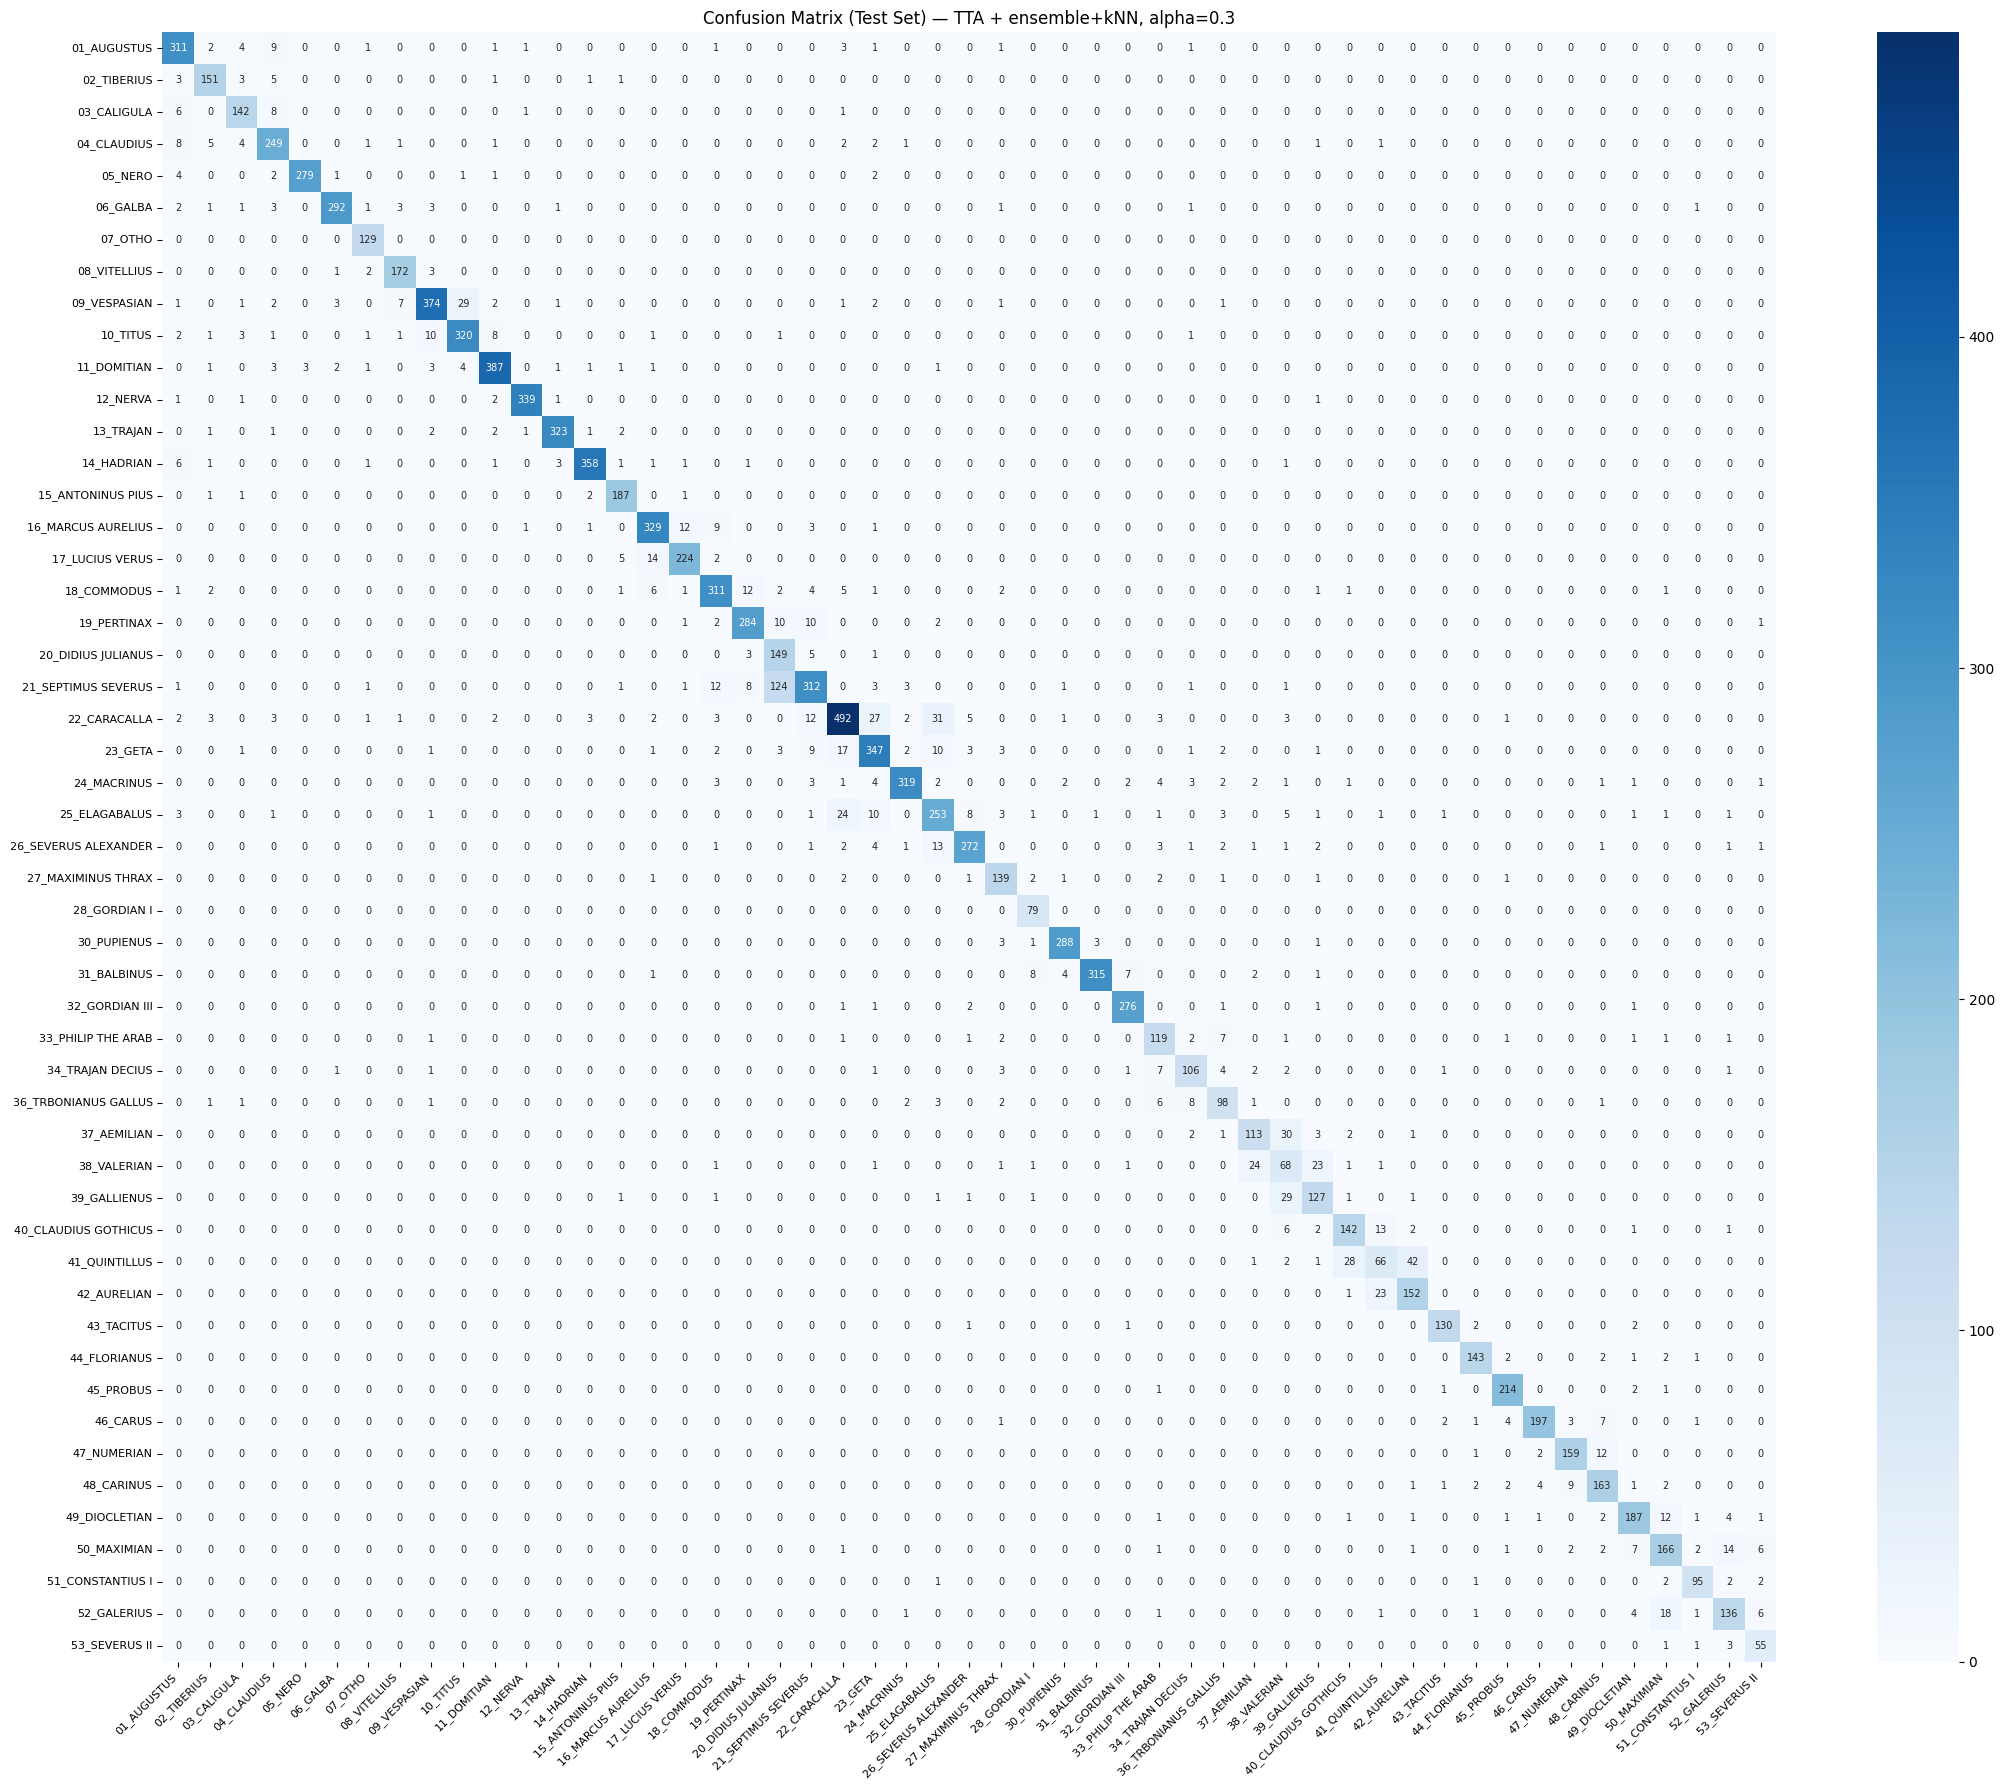

In [27]:
class_order = sorted(range(num_classes), key=lambda i: name_to_prefix[idx_to_label[i]])
display_names = [f"{name_to_prefix[idx_to_label[i]]:02d}_{idx_to_label[i]}" for i in class_order]

cm = np.zeros((num_classes, num_classes), dtype=int)
with torch.no_grad():
    for feats, targets in test_loader:
        targets = targets.to(device)
        preds = fused_predict(feats, best_alpha).argmax(-1)
        for t, p in zip(targets.cpu(), preds.cpu()):
            cm[t.item(), p.item()] += 1
cm = cm[np.ix_(class_order, class_order)]

df_cm = pd.DataFrame(cm, index=display_names, columns=display_names)
plt.figure(figsize=(22, 18))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 7})
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title(f'Confusion Matrix (Test Set) — TTA + ensemble+kNN, alpha={best_alpha}')
plt.tight_layout()
plt.show()


In [28]:
TOP_CONFUSIONS = 3
total_correct = int(cm.diagonal().sum())
total = int(cm.sum())
print(f'Overall test accuracy: {total_correct}/{total} = {total_correct/total:.4f}')
print(f'Classes: {num_classes}\n')

row_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
order_worst_first = np.argsort(row_acc)

print('Per-class breakdown (sorted by accuracy, worst first):')
for i in order_worst_first:
    n_total = int(cm[i].sum())
    n_correct = int(cm[i, i])
    acc = n_correct / max(n_total, 1)
    print(f'\n{display_names[i]}: {n_correct}/{n_total} correct  acc={acc:.3f}')
    off = sorted(
        ((j, int(cm[i, j])) for j in range(num_classes) if j != i and cm[i, j] > 0),
        key=lambda x: -x[1],
    )
    if not off:
        print('  (no mistakes)')
        continue
    for j, count in off[:TOP_CONFUSIONS]:
        print(f'  -> predicted as {display_names[j]}: {count} ({count / max(n_total, 1):.1%})')
    remaining = sum(c for _, c in off[TOP_CONFUSIONS:])
    if remaining:
        print(f'  -> other classes: {remaining}')


Overall test accuracy: 11038/12427 = 0.8882
Classes: 51

Per-class breakdown (sorted by accuracy, worst first):

41_QUINTILLUS: 66/140 correct  acc=0.471
  -> predicted as 42_AURELIAN: 42 (30.0%)
  -> predicted as 40_CLAUDIUS GOTHICUS: 28 (20.0%)
  -> predicted as 38_VALERIAN: 2 (1.4%)
  -> other classes: 2

38_VALERIAN: 68/122 correct  acc=0.557
  -> predicted as 37_AEMILIAN: 24 (19.7%)
  -> predicted as 39_GALLIENUS: 23 (18.9%)
  -> predicted as 18_COMMODUS: 1 (0.8%)
  -> other classes: 6

21_SEPTIMUS SEVERUS: 312/469 correct  acc=0.665
  -> predicted as 20_DIDIUS JULIANUS: 124 (26.4%)
  -> predicted as 18_COMMODUS: 12 (2.6%)
  -> predicted as 19_PERTINAX: 8 (1.7%)
  -> other classes: 13

37_AEMILIAN: 113/152 correct  acc=0.743
  -> predicted as 38_VALERIAN: 30 (19.7%)
  -> predicted as 39_GALLIENUS: 3 (2.0%)
  -> predicted as 34_TRAJAN DECIUS: 2 (1.3%)
  -> other classes: 4

39_GALLIENUS: 127/163 correct  acc=0.779
  -> predicted as 38_VALERIAN: 29 (17.8%)
  -> predicted as 15_ANTON

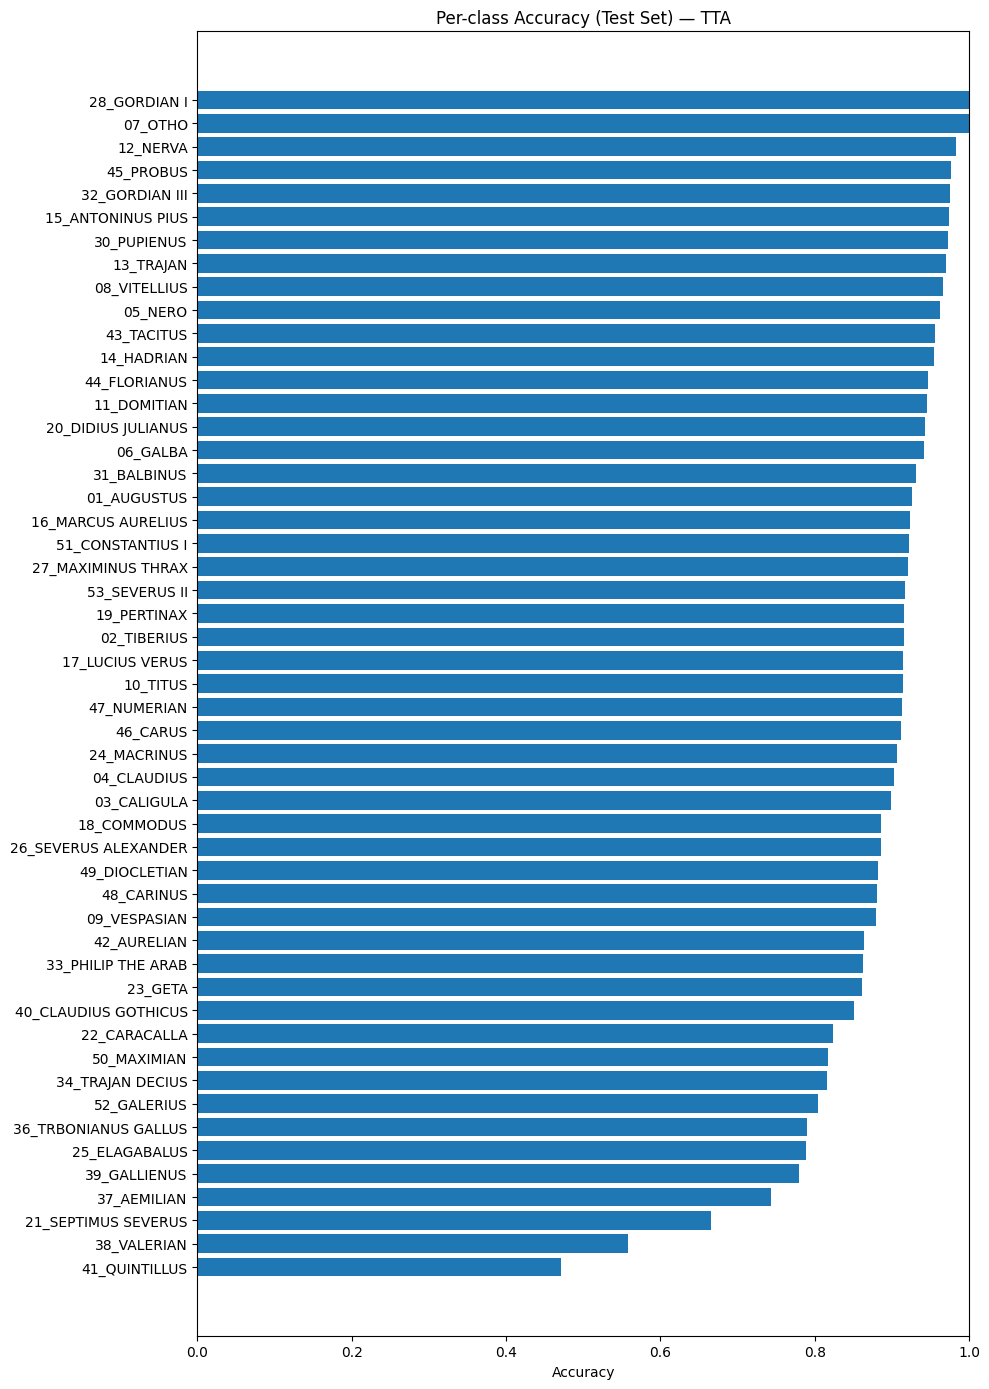

             Emperor  Accuracy
       41_QUINTILLUS  0.471429
         38_VALERIAN  0.557377
 21_SEPTIMUS SEVERUS  0.665245
         37_AEMILIAN  0.743421
        39_GALLIENUS  0.779141
       25_ELAGABALUS  0.788162
36_TRBONIANUS GALLUS  0.790323
         52_GALERIUS  0.804734
    34_TRAJAN DECIUS  0.815385
         50_MAXIMIAN  0.817734
        22_CARACALLA  0.824121
40_CLAUDIUS GOTHICUS  0.850299
             23_GETA  0.861042
  33_PHILIP THE ARAB  0.862319
         42_AURELIAN  0.863636
        09_VESPASIAN  0.880000
          48_CARINUS  0.881081
       49_DIOCLETIAN  0.882075
26_SEVERUS ALEXANDER  0.885993
         18_COMMODUS  0.886040
         03_CALIGULA  0.898734
         04_CLAUDIUS  0.902174
         24_MACRINUS  0.906250
            46_CARUS  0.912037
         47_NUMERIAN  0.913793
            10_TITUS  0.914286
     17_LUCIUS VERUS  0.914286
         02_TIBERIUS  0.915152
         19_PERTINAX  0.916129
       53_SEVERUS II  0.916667
  27_MAXIMINUS THRAX  0.920530
    51_C

In [29]:
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
acc_df = pd.DataFrame({'Emperor': display_names, 'Accuracy': per_class_acc}).sort_values('Accuracy')

plt.figure(figsize=(10, 14))
plt.barh(acc_df['Emperor'], acc_df['Accuracy'])
plt.xlabel('Accuracy')
plt.title('Per-class Accuracy (Test Set) — TTA')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(acc_df.to_string(index=False))
